In [6]:
import netCDF4 as nc
import glob
import xarray as xr
import numpy as np
import datetime
from matplotlib import pyplot as plt, animation
import matplotlib.gridspec as gridspec

from scipy import signal
from scipy.interpolate import RegularGridInterpolator

import os
import sys as sys
sys.path.append('../src/')
import swot_swell_utils as swell
from  lib_filters_obp import *
from wave_physics_functions import wavespec_Efth_to_Ekxky
import cmocean
import cmocean.cm as cmo
import matplotlib.colors as mcolors

from ipywidgets import interact, IntSlider, FloatRangeSlider,  FloatSlider, ToggleButtons
from ipywidgets import interactive_output, GridBox, Layout
from IPython.display import display
from ipywidgets import VBox


lightcmap = cmocean.tools.lighten(cmo.ice, 1)
lightcmap2 = cmocean.tools.lighten(cmo.ice_r, 1)


In [7]:
def phase_speed_from_k(k,depth=None,g=9.81):
    if depth == 'None':
        # print("Deep water approximation")
        C=np.sqrt(g/k)
    else:
        # print("General case")
        C=np.sqrt(g*np.tanh(k*depth)/k)
    return C
            
def k_from_f(f,D=1000.,g=9.81):
    # inverts the linear dispersion relation (2*pi*f)^2=g*k*tanh(k*dep) to get 
    #k from f and dep. 2 Arguments: f and dep. 
    eps=0.000001
    sig=np.array(2*np.pi*f)
    if D > 1000.:
        # print("Deep water approximation")
        k=sig**2/g
    else:
        Y=D*sig**2/g
        X=np.sqrt(Y)
        I=1
        F=1.
        while (abs(np.max(F)) > eps):
            H=np.tanh(X)
            F=Y-(X*H)
            FD=-H-(X/(np.cosh(X)**2))
            X=X-(F/FD)

        k=X/D

    return k # wavenumber

k=k_from_f(0.0125,D=4500.,g=9.81)
print('K:',k,2*np.pi/k)

    
def group_speed_from_k(k,depth=None,g=9.81):
    C=phase_speed_from_k(k,depth=depth,g=g)
    if depth == 'None':
        # print("Deep water approximation")
        Cg=C/2
    else:
        # print("General case")
        Cg=C*(0.5+ ((k*depth)/(np.sinh(2*k*depth)) ))
    return Cg

# With median removed: 
#lon,lat,angt,Hs,dm,LE: 229.45789 -54.08535 160.87035 0.02013833713086805 70.87034606933594 4176.816630735993
#lon,lat,angt,Hs,dm,LE: 228.64806 -54.63744 160.66437 0.01710350563428665 70.66436767578125 3074.537174311059
#lon,lat,angt,Hs,dm,LE: 228.85414 -54.982124 160.45526 0.02384015252689848 70.45526123046875 2645.276832913063
#lon,lat,angt,Hs,dm,LE: 229.06448 -55.326336 160.24129 0.02025056251208003 70.24128723144531 2355.668798094848

tsudata=[[ 229.45789, -54.08535, 160.87035, 0.02013833713086805, 26.163885857056492 ,4176.816630735993], \
         [ 228.64806,  -54.63744, 160.66437, 0.01710350563428665, 25.65917889486755, 3074.537174311059], 
         [  228.85414, -54.982124, 160.45526, 26.858228645074476, 26.858228645074476, 2645.276832913063],
          [ 229.06448, -55.326336, 160.24129, 28.188898511754836, 28.18889851175483, 2355.668798094848]]
tsudata = np.array(tsudata)

# Create xarray dataset
ds = xr.Dataset(
    {
        "lon": ("obs", tsudata[:, 0]),
        "lat": ("obs", tsudata[:, 1]),
        "track_angle": ("obs", tsudata[:, 2]),
        "Hs": ("obs", tsudata[:, 3]),
        "dm": ("obs", tsudata[:, 4]),
        "LE": ("obs", tsudata[:, 5])
    },
    coords={
        "obs": np.arange(tsudata.shape[0])  # dimension for each observation
    }
)

i=2;j=3
Cg1=group_speed_from_k(2*np.pi/ds.LE[i].values,depth=4000)
Cg2=group_speed_from_k(2*np.pi/ds.LE[j].values,depth=4000)

alpha,beta=swell.dist_sphere(ds.lon[i].values,ds.lon[j].values,ds.lat[i].values,ds.lat[j].values)
RE=2E7/np.pi
print(ds.track_angle[i].values,beta,beta*180/np.pi)
print(Cg1,Cg2,alpha,alpha*RE,'beta:',beta,(ds.dm[i].values+180)*np.pi/180,np.cos(beta-(ds.dm[i].values+180)*np.pi/180))

#Cg1=group_speed_from_k(2*np.pi/4176.816630735993,depth=4600)
#Cg2=group_speed_from_k(2*np.pi/4176.816630735993,depth=2200)

print('Cg1,Cg2:',Cg1,Cg2)


r=Cg2/Cg1
print(alpha*RE*np.cos(beta-(ds.dm[i].values+180)*np.pi/180)*(1/(1-r)))

K: 0.000628797426165224 9992.383947081558
160.45526 2.8071803545650913 160.8395866486177
32.132922600096045 30.322967357455248 0.006363281119157522 40509.9057758899 beta: 2.8071803545650913 3.610357174699798 0.6944242862630877
Cg1,Cg2: 32.132922600096045 30.322967357455248
499422.9855096841


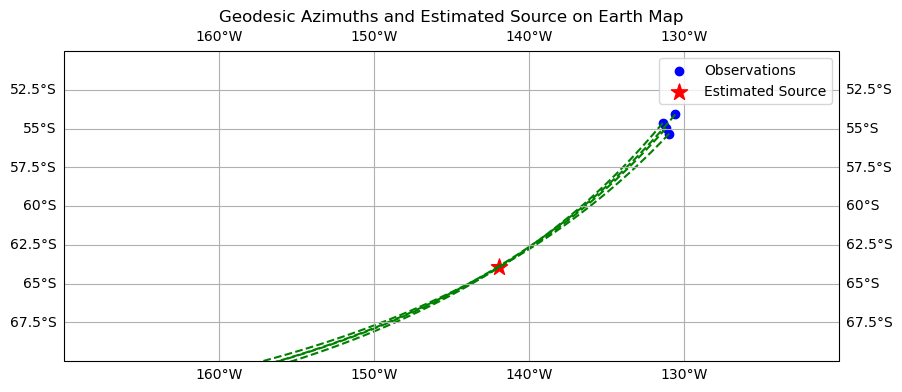

dist: 1163364.850463369


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod

# Observations
lon = np.array([229.45789, 228.64806, 228.85414, 229.06448])
lat = np.array([-54.08535, -54.63744, -54.982124, -55.326336])
dm = 180+np.array([26.163885857056492, 25.65917889486755, 
               26.858228645074476, 28.18889851175483])  # degrees

geod = Geod(ellps="WGS84")

# Function to compute geodesic line points
def geodesic_line(lat0, lon0, az, npts=100):
    # far endpoint 3000 km along azimuth
    lon1, lat1, _ = geod.fwd(lon0, lat0, az, 3e6)
    # intermediate points along geodesic
    points = geod.npts(lon0, lat0, lon1, lat1, npts)
    # separate lon/lat arrays
    lons = [lon0] + [p[0] for p in points] + [lon1]
    lats = [lat0] + [p[1] for p in points] + [lat1]
    return np.array(lons), np.array(lats)

# Function to estimate source on the sphere (least-squares)
def solve_source_spherical(lat, lon, az):
    phi = np.deg2rad(lat)
    lam = np.deg2rad(lon)
    alpha = np.deg2rad(az)

    def sph2cart(phi, lam):
        return np.array([np.cos(phi)*np.cos(lam),
                         np.cos(phi)*np.sin(lam),
                         np.sin(phi)])

    planes = []
    for p, l, a in zip(phi, lam, alpha):
        pv = sph2cart(p, l)
        n = np.array([-np.sin(p)*np.cos(l), -np.sin(p)*np.sin(l), np.cos(p)])
        e = np.array([-np.sin(l), np.cos(l), 0.0])
        t = np.cos(a)*n + np.sin(a)*e
        planes.append(np.cross(pv, t))

    P = np.stack(planes)
    U, s, Vt = np.linalg.svd(P)
    source_vec = Vt.T[:, -1]
    source_vec /= np.linalg.norm(source_vec)
    lat_s = np.rad2deg(np.arcsin(source_vec[2]))
    lon_s = np.rad2deg(np.arctan2(source_vec[1], source_vec[0]))
    return lat_s, lon_s

lat_s, lon_s = solve_source_spherical(lat, lon, dm)

# Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-170, -120, -70, -50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)

# Observations and source
ax.scatter(lon, lat, c='blue', label='Observations', transform=ccrs.PlateCarree())
ax.scatter(lon_s, lat_s, c='red', marker='*', s=150,
           label='Estimated Source', transform=ccrs.PlateCarree())

# Azimuth lines
for lo, la, az in zip(lon, lat, dm):
    lons, lats = geodesic_line(la, lo, az)
    ax.plot(lons, lats, '--', c='green', transform=ccrs.Geodetic())

plt.legend()
plt.title("Geodesic Azimuths and Estimated Source on Earth Map")
plt.show()

alpha,beta=swell.dist_sphere(ds.lon[2].values,lon_s,ds.lat[2].values,lat_s)
dist_s=alpha*RE
print('dist:',dist_s)

In [9]:
E=(0.014/4)**2*10000
A=40*120*1E6
E1=E*A/1E6
E2=E*dist_s*2*np.pi*100E3/1E6
E3=E*540E3*2*np.pi*100E3/1E6
print('Energy in Mega-Joules (over obs region only, over 100 km wide annulus):',E1,E2,E3)
print('size of cube of ice with potential energy at 100 eight):',(E1)**(1/3),(E2)**(1/3),(E3)**(1/3))


Energy in Mega-Joules (over obs region only, over 100 km wide annulus): 588.0 89543.05245767755 41563.270806992965
size of cube of ice with potential energy at 100 eight): 8.377718728240055 44.73807552738995 34.639363690702375
